# Credit Card Fraud Detection - Logistic Regression vs. XGBoost

This notebook builds a leakage-free, reproducible pipeline for detecting credit card fraud and compares two modeling approaches on the **same held-out test set**:

1. **Logistic Regression** (baseline) - with feature preprocessing and `class_weight="balanced"`.
2. **XGBoost** (main focus) - with `scale_pos_weight` to handle class imbalance, no resampling.

Class imbalance is handled entirely through **class weighting**, not oversampling. All metrics and plots below are produced by running the code in this notebook; none are hardcoded.

In [ ]:
# Imports and reproducibility
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn pipeline building, data processing, and evaluation metrics
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

# XGBoost gradient boosting classifier
from xgboost import XGBClassifier

# Set global random seed for complete experimental reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Credit Card Fraud Dataset

In [ ]:
# Path to the Kaggle European Credit Card Fraud dataset
DATA_PATH = "./data/creditcard.csv"

# Step 1.1: Load dataset into pandas DataFrame
df = pd.read_csv(DATA_PATH)

# Display dataset dimensions (rows, columns)
print(f"Dataset shape: {df.shape}")

# Step 1.2: Calculate raw counts and percentages for legitimate (0) vs. fraudulent (1) transactions
class_counts = df["Class"].value_counts().sort_index()
class_pct = (df["Class"].value_counts(normalize=True).sort_index() * 100).round(4)

print("\nClass distribution (counts):")
print(class_counts.rename(index={0: "Non-fraud (0)", 1: "Fraud (1)"}))

print("\nClass distribution (%):")
print(class_pct.rename(index={0: "Non-fraud (0)", 1: "Fraud (1)"}))

Dataset shape: (284807, 31)

Class distribution (counts):
Class
Non-fraud (0)    284315
Fraud (1)           492
Name: count, dtype: int64

Class distribution (%):
Class
Non-fraud (0)    99.8273
Fraud (1)         0.1727
Name: proportion, dtype: float64


In [ ]:
# Step 1.3: Inspect DataFrame structure, column dtypes, non-null counts, and memory footprint
print("--- df.info() ---")
df.info()

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float

In [ ]:
# Step 1.4: Compute summary statistics (mean, std, min, max, quartiles) across all features
print("--- df.describe() ---")
df.describe()

--- df.describe() ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 2. Data Cleaning

We check for missing values, duplicate transactions, and clearly invalid rows (e.g. negative amounts or out-of-range class labels), and confirm column dtypes. This section is deliberately **model-agnostic**: no scaling or distributional transformations are applied here, since those are only appropriate for Logistic Regression and are handled later, inside that model's own section.

In [ ]:
# Step 2.1: Check for missing / null values across all columns
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0]
print("Columns with missing values:")
print(missing_counts if not missing_counts.empty else "None found.")

# Step 2.2: Identify duplicate transaction rows
n_duplicates = df.duplicated().sum()
print(f"\nDuplicate rows found: {n_duplicates}")

# Drop duplicate rows to prevent data leakage between train and test splits
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {df.shape}")

Columns with missing values:
None found.

Duplicate rows found: 1081
Shape after dropping duplicates: (283726, 31)


In [ ]:
# Step 2.3: Check for domain-specific invalid rows (negative Amount, invalid Class label, negative Time)
invalid_amount = (df["Amount"] < 0).sum()
invalid_class = (~df["Class"].isin([0, 1])).sum()
invalid_time = (df["Time"] < 0).sum()

print(f"Rows with negative Amount   : {invalid_amount}")
print(f"Rows with invalid Class     : {invalid_class}")
print(f"Rows with negative Time     : {invalid_time}")

# Filter out invalid rows if detected
if invalid_amount:
    df = df[df["Amount"] >= 0]
if invalid_time:
    df = df[df["Time"] >= 0]
if invalid_class:
    df = df[df["Class"].isin([0, 1])]

df = df.reset_index(drop=True)
print(f"\nShape after removing invalid rows: {df.shape}")

Rows with negative Amount   : 0
Rows with invalid Class     : 0
Rows with negative Time     : 0

Shape after removing invalid rows: (283726, 31)


In [ ]:
# Step 2.4: Verify and enforce correct data types (numeric for features, int for binary Class target)
print("Dtypes before correction:")
print(df.dtypes.value_counts())

numeric_cols = [c for c in df.columns if c != "Class"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
df["Class"] = df["Class"].astype(int)

print("\nAny NaNs introduced by dtype coercion:", int(df[numeric_cols].isna().sum().sum()))
print("Dtypes after correction:")
print(df.dtypes.value_counts())

Dtypes before correction:
float64    30
int64       1
Name: count, dtype: int64

Any NaNs introduced by dtype coercion: 0
Dtypes after correction:
float64    30
int64       1
Name: count, dtype: int64


## 3. Stratified Train/Test Split


In [ ]:
# Step 3.1: Separate feature matrix X (predictors) and target vector y (Class label)
X = df.drop(columns="Class")
y = df["Class"]

# Step 3.2: Perform an 80/20 stratified train/test split to maintain class ratio without data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Step 3.3: Verify shape and check class proportion consistency between splits
print(f"Train shape: {X_train.shape}")
print(f"Test shape : {X_test.shape}")

print("\nTrain class distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(4))

print("\nTest class distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(4))

# Sanity check: verify that train and test fraud rates match within tight tolerance
train_rate = y_train.mean()
test_rate = y_test.mean()
print(f"\nFraud rate difference (train - test): {abs(train_rate - test_rate):.6f}")

Train shape: (226980, 30)
Test shape : (56746, 30)

Train class distribution (%):
Class
0    99.8335
1     0.1665
Name: proportion, dtype: float64

Test class distribution (%):
Class
0    99.8326
1     0.1674
Name: proportion, dtype: float64

Fraud rate difference (train - test): 0.000009


## 4. Logistic Regression Baseline

In [ ]:
# Step 4.1: Custom IQR Outlier Clipper Transformer (fits bounds on training data only)
class IQRClipper(BaseEstimator, TransformerMixin):
    """Clips feature values to the [Q1 - 1.5*IQR, Q3 + 1.5*IQR] range, fit on training data only."""

    def fit(self, X, y=None):
        self.q1_ = np.percentile(X, 25, axis=0)
        self.q3_ = np.percentile(X, 75, axis=0)
        self.iqr_ = self.q3_ - self.q1_
        return self

    def transform(self, X):
        lower = self.q1_ - 1.5 * self.iqr_
        upper = self.q3_ + 1.5 * self.iqr_
        return np.clip(X, lower, upper)


# Step 4.2: Preprocessing pipeline for non-PCA features (Time & Amount):
# Impute missing values -> Clip extreme outliers -> Apply Yeo-Johnson PowerTransformation for skewness
non_pca_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("outlier_clipping", IQRClipper()),
    ("power_transform", PowerTransformer(method="yeo-johnson")),
])

# Step 4.3: ColumnTransformer applying non_pca_pipeline to Time/Amount while passing V1-V28 through
preprocessor = ColumnTransformer(
    transformers=[("non_pca", non_pca_pipeline, ["Time", "Amount"])],
    remainder="passthrough",  # V1-V28 are already PCA-transformed & standardized
)

# Step 4.4: Complete Logistic Regression Pipeline with class_weight="balanced"
lr_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(class_weight="balanced")),
])

In [ ]:
# Step 4.5: Define hyperparameter grid for regularization parameter C
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear"],
    "model__max_iter": [500],
}

# Step 4.6: Set up 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Step 4.7: Execute GridSearchCV optimizing average_precision (PR-AUC)
lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
)

lr_grid_search.fit(X_train, y_train)

# Step 4.8: Display optimal parameters and best cross-validation PR-AUC score
print("Best parameters:", lr_grid_search.best_params_)
print(f"Best CV average precision (PR-AUC): {lr_grid_search.best_score_:.4f}")

Best parameters: {'model__C': 1, 'model__max_iter': 500, 'model__solver': 'liblinear'}
Best CV average precision (PR-AUC): 0.7557


In [ ]:
# Step 4.9: Predict binary class labels and fraud probability scores on the held-out test set
y_pred_lr = lr_grid_search.predict(X_test)
y_prob_lr = lr_grid_search.predict_proba(X_test)[:, 1]  # probability of positive class (fraud)

## 5. Evaluation of Logistic Regression

In [ ]:
# Step 5.1: Define reusable evaluation function computing key fraud-detection metrics
def evaluate_model(name, y_true, y_pred, y_prob):
    """Compute a standard set of fraud-detection metrics for one model's predictions."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "Model": name,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }


# Step 5.2: Evaluate Logistic Regression performance on test set
lr_metrics = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)

print("Logistic Regression — test set performance")
for key, value in lr_metrics.items():
    if key != "Model":
        print(f"  {key:10s}: {value:.4f}" if isinstance(value, float) else f"  {key:10s}: {value}")

print("\nConfusion matrix (rows = actual, cols = predicted):")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression — test set performance
  Precision : 0.0551
  Recall    : 0.8737
  F1        : 0.1037
  ROC-AUC   : 0.9620
  PR-AUC    : 0.6705
  TN        : 55229
  FP        : 1422
  FN        : 12
  TP        : 83

Confusion matrix (rows = actual, cols = predicted):
[[55229  1422]
 [   12    83]]


## 6. XGBoost Model (Main Focus)


In [ ]:
# Step 6.1: Compute scale_pos_weight = (# negative samples) / (# positive samples) on training set only
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()
scale_pos_weight = n_negative / n_positive

print(f"Non-fraud transactions (train): {n_negative}")
print(f"Fraud transactions (train)    : {n_positive}")
print(f"scale_pos_weight              : {scale_pos_weight:.2f}")

Non-fraud transactions (train): 226602
Fraud transactions (train)    : 378
scale_pos_weight              : 599.48


In [ ]:
# Step 6.2: Instantiate XGBoost Classifier configured with scale_pos_weight (no oversampling used)
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    gamma=0,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Step 6.3: Fit XGBoost directly on raw training features (decision trees do not require scaling)
xgb_model.fit(X_train, y_train)

# Step 6.4: Predict binary class labels and fraud probability scores on the test set
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost training complete.")

XGBoost training complete.


## 7. Evaluation of XGBoost


In [ ]:
# Step 7.1: Evaluate XGBoost performance on test set
xgb_metrics = evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)

print("XGBoost — test set performance")
for key, value in xgb_metrics.items():
    if key != "Model":
        print(f"  {key:10s}: {value:.4f}" if isinstance(value, float) else f"  {key:10s}: {value}")

print("\nConfusion matrix (rows = actual, cols = predicted):")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost — test set performance
  Precision : 0.9259
  Recall    : 0.7895
  F1        : 0.8523
  ROC-AUC   : 0.9825
  PR-AUC    : 0.8205
  TN        : 56645
  FP        : 6
  FN        : 20
  TP        : 75

Confusion matrix (rows = actual, cols = predicted):
[[56645     6]
 [   20    75]]


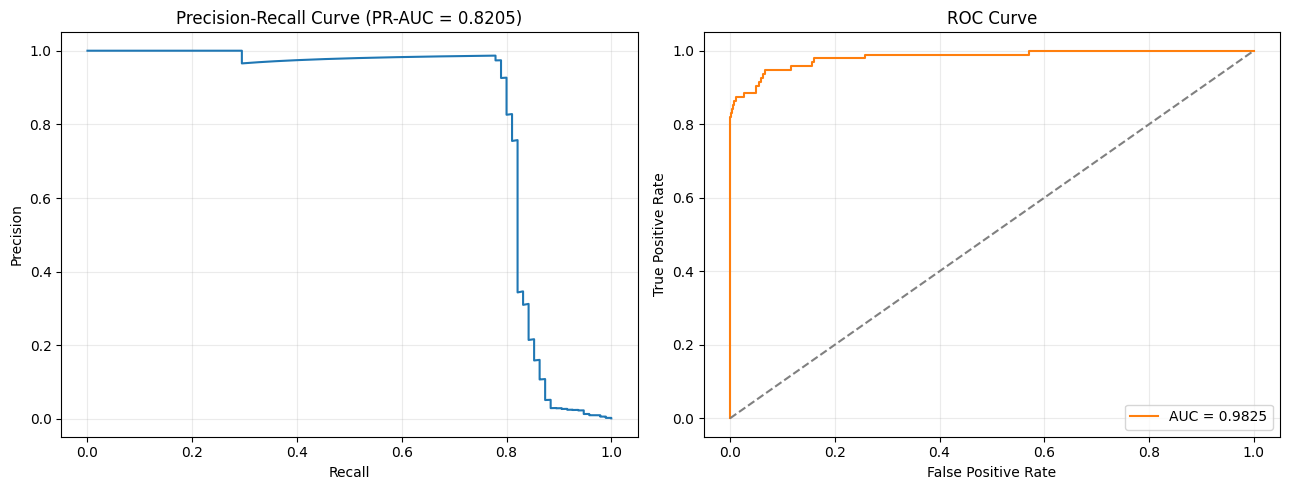

In [ ]:
# Step 7.2: Plot Precision-Recall Curve and ROC Curve for visual metric inspection
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_xgb)
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot Precision-Recall Curve
axes[0].plot(recall_curve, precision_curve, color="tab:blue")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"Precision-Recall Curve (PR-AUC = {xgb_metrics['PR-AUC']:.4f})")
axes[0].grid(alpha=0.25)

# Plot Receiver Operating Characteristic (ROC) Curve
axes[1].plot(fpr, tpr, color="tab:orange", label=f"AUC = {xgb_metrics['ROC-AUC']:.4f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 8. Model Comparison

In [ ]:
# Step 8.1: Create side-by-side comparison DataFrame summarizing metrics and confusion matrix values
comparison_df = pd.DataFrame([lr_metrics, xgb_metrics]).set_index("Model")
comparison_df.round(4)

,Precision,Recall,F1,ROC-AUC,PR-AUC,TN,FP,FN,TP
Model,,,,,,,,,
Logistic Regression,0.0551,0.8737,0.1038,0.9620,0.6705,55229,1422,12,83
XGBoost,0.9259,0.7895,0.8523,0.9825,0.8205,56645,6,20,75
